In [1]:
import json
import os 
import numpy as np
from pathlib import Path
from turnmill_process import TurnmillProcess

test_dir = Path.cwd().parent.parent.resolve() / "testdata/Diameter32Z3"
test_paths = os.listdir(test_dir)

break_list = []
processes = []

In [2]:
for file in test_paths:
    if file.endswith('.json'):
        data_dict = json.load(open(os.path.join(test_dir, file), "r", encoding="utf-8"))
        process = TurnmillProcess(data_dict, nChannels=3)
        channel_data = np.array([data_dict[f"Channel_{i}"]["Signal"] for i in range(1, 4)])
        num_samples = channel_data.shape[1]
        dt = 1 / data_dict["File_Header"]["SampleFrequency"]  # time interval between samples
        break_list.append(data_dict["break"])

        for j in range(channel_data.shape[1]):
            process.add_datapoint(timestamp=dt*j, values=channel_data[:, j].tolist())

        processes.append(process)

In [3]:
print(f"Number of breaks: {sum(break_list)}/{len(break_list)}")
print(test_paths)

Number of breaks: 44/63
['20.json', '61.json', '36.json', '41.json', '16.json', '57.json', '6.json', '7.json', '56.json', '17.json', '40.json', '37.json', '60.json', '21.json', '47.json', '10.json', '51.json', '0.json', '26.json', '30.json', '31.json', '27.json', '1.json', '50.json', '11.json', '46.json', '2.json', '28.json', '53.json', '12.json', '45.json', '32.json', '24.json', '49.json', '48.json', '25.json', '33.json', '44.json', '13.json', '52.json', '29.json', '3.json', '34.json', '8.json', '22.json', '59.json', '18.json', '38.json', '4.json', '55.json', '14.json', '43.json', '42.json', '15.json', '54.json', '5.json', '39.json', '19.json', '58.json', '23.json', '62.json', '9.json', '35.json']


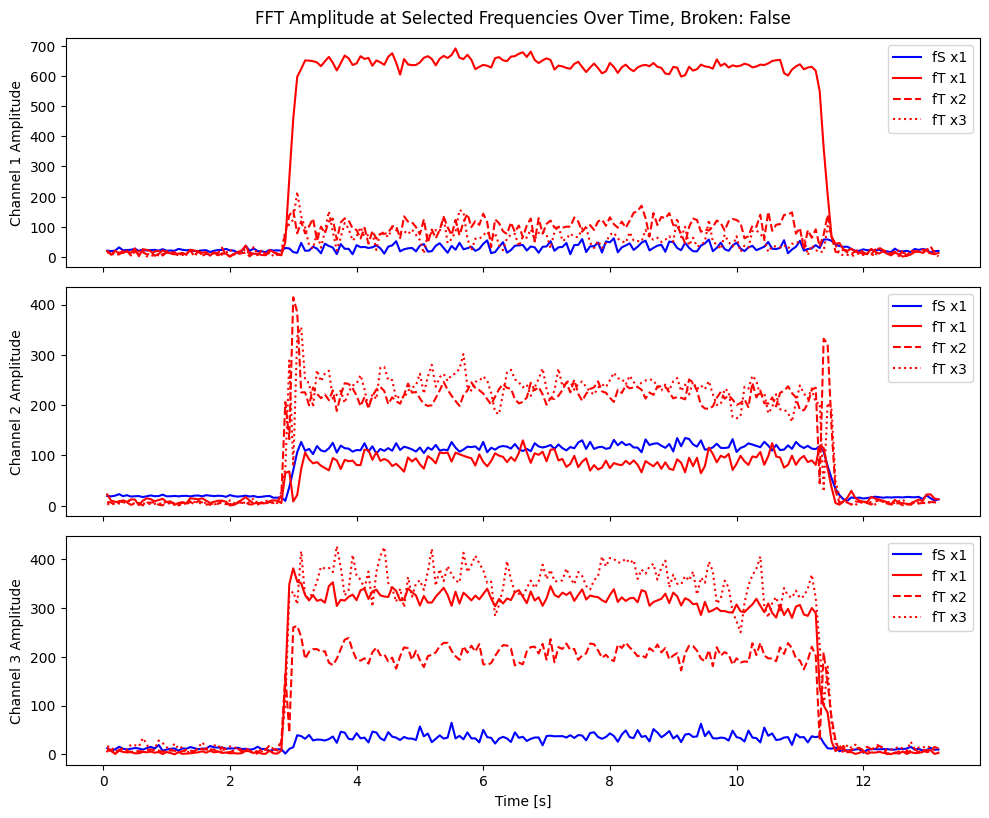

In [4]:
import matplotlib.pyplot as plt

def do_fft(process, block_size=128):
    time = process.get_timestamps()
    dt = time[1] - time[0]
    freq = np.fft.rfftfreq(block_size, d=dt)
    f_signal = np.zeros((block_size//2 + 1, (len(time)-block_size)//(block_size//2)+1, 3), dtype=complex)
    signal = np.array([process.get_channel_array(i) for i in range(3)])

    time_segs = []

    iter = 0

    while iter + block_size <= signal.shape[1]:
        seg_signal = signal[:, iter:iter+block_size]
        seg_time = time[iter:iter+block_size]
        f_signal[:, iter//(block_size//2), :] = np.fft.rfft(seg_signal).T
        time_segs.append(seg_time[block_size//2])
        iter += block_size//2

    return freq, f_signal, np.array(time_segs)

def plot_at_frequency(process_idx, block_size, harmonics: dict, time_window=None):
    process = processes[process_idx]

    spindle_f = process.fg
    tooth_f = process.fp

    frequencies = [spindle_f * h for h in harmonics['spindle']] + [tooth_f * h for h in harmonics['tooth']]
    freq_labels = ["fS x"+str(h) for h in harmonics['spindle']] + ["fT x"+str(h) for h in harmonics['tooth']]

    freq, f_signal, time_segs = do_fft(process, block_size=block_size)
    freq_indices = [np.argmin(np.abs(freq - f)) for f in frequencies]

    fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    #spindle frequencies blue, tooth frequencies red
    colors = ['blue'] * len(harmonics['spindle']) + ['red'] * len(harmonics['tooth'])

    # Line types for different harmonics
    linestyles = ['solid', 'dashed', 'dotted', 'dashdot']
    matched_linestyles = linestyles[:len(harmonics['spindle'])] + linestyles[:len(harmonics['tooth'])]

    for i in range(3):  # for each channel
        for f_idx, label, color, linestyle in zip(freq_indices, freq_labels, colors, matched_linestyles):
            ax[i].plot(time_segs, np.abs(f_signal[f_idx, :, i]), label=label, color=color, linestyle=linestyle)
        ax[i].set_ylabel(f'Channel {i+1} Amplitude')
        ax[i].legend( loc='upper right')

    ax[2].set_xlabel('Time [s]')
    if time_window:
        ax[2].set_xlim(time_window)
    plt.tight_layout()
    plt.title(f'FFT Amplitude at Selected Frequencies Over Time, Broken: {break_list[process_idx]}', y=3.2)
    plt.show()

# Example usage:
harmonics = {'spindle': [1],
             'tooth': [1, 2, 3]}

plot_at_frequency(process_idx=0, block_size=512, harmonics=harmonics, time_window=None)

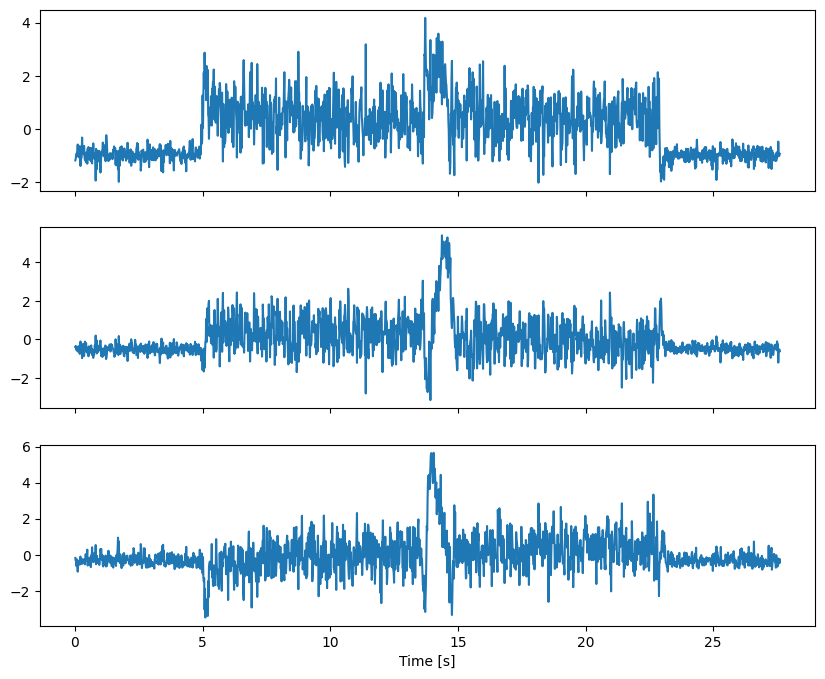

Broken:  False
